# Textual Attention Analysis


This notebook operationalises the concept of “textual attention” within a corpus of critical writing on Alexis Wright. The term is used to describe the extent to which particular theorists are not only cited, but actively mobilised as interpretive frameworks in the analysis of Wright’s work.

The study proceeds from the premise that citation alone is an insufficient indicator of intellectual influence. Bibliographies record presence, but they do not capture the distribution, intensity, or functional role of theoretical engagement within the body of a text. Accordingly, this notebook seeks to measure how attention is allocated across competing theoretical frames, and to distinguish between peripheral reference and sustained interpretive reliance.

Two primary research objectives guide the analysis. First, to identify the key theorists through whom Wright’s work is most frequently interpreted. Second, to quantify the degree of textual attention afforded to these figures, thereby establishing a comparative measure of their interpretive prominence.

Methodologically, the notebook combines corpus processing with frequency-based and positional analysis. Mentions of theorists are detected across the full text of each document, and weighted according to their distribution and recurrence. This enables a more nuanced account of critical engagement, capturing not only who is cited, but how substantially their frameworks shape scholarly readings of Wright’s fiction.


In [1]:
import os
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import spacy
import re


In [2]:
import spacy

nlp = spacy.load("en_core_web_trf")

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

documents = {}

for file in sorted(DATA_DIR.glob("*.txt")):
    text = file.read_text(encoding="utf-8").strip()
    if text:
        documents[file.stem] = text
    else:
        print(f"Skipping empty file: {file.name}")

print(f"Loaded {len(documents)} non-empty documents from {DATA_DIR}")

if not documents:
    raise ValueError("No documents were loaded. Check your data path and file contents.")

Loaded 110 non-empty documents from /Users/FMOR/Documents/GitHub/citational_refusal/data/processed


In [4]:
list(documents.keys())[:5]

["01 Sep 2007 - Australian Women's Book Review: Online - Trove",
 '2006-01-01__ferrier-carole__australian-womens-book-review__the-best-australian-novel-for-years__book-review',
 '2006-08-19__ravenscroft-alison__the-age__when-the-narrators-art-matches-the-magical-storytelling__book-review',
 '2006-09-02__anonymous__the-canberra-times__calming-influence-in-balance-fraught-with-pain__book-review',
 '2006-09-09__osullivan-jane__the-age__from-here-to-carpentaria__book-review']

In [5]:
doc_names = list(documents.keys())
doc_texts = list(documents.values())

processed_docs = []

total_docs = len(doc_texts)
print(f"Starting NER over {total_docs} documents...")

for i, doc in enumerate(nlp.pipe(doc_texts, batch_size=4), start=1):
    processed_docs.append(doc)

    if i % 5 == 0 or i == total_docs:
        print(f"Processed {i}/{total_docs} documents")

print(f"Finished processing {len(processed_docs)} documents.")

Starting NER over 110 documents...
Processed 5/110 documents
Processed 10/110 documents
Processed 15/110 documents
Processed 20/110 documents
Processed 25/110 documents
Processed 30/110 documents
Processed 35/110 documents
Processed 40/110 documents
Processed 45/110 documents
Processed 50/110 documents
Processed 55/110 documents
Processed 60/110 documents
Processed 65/110 documents
Processed 70/110 documents
Processed 75/110 documents
Processed 80/110 documents
Processed 85/110 documents
Processed 90/110 documents
Processed 95/110 documents
Processed 100/110 documents
Processed 105/110 documents
Processed 110/110 documents
Finished processing 110 documents.


In [6]:
# Extract PERSON entities from each document
person_entities_by_doc = {}

for doc_name, doc in zip(doc_names, processed_docs):
    people = [ent.text.strip() for ent in doc.ents if ent.label_ == "PERSON"]
    person_entities_by_doc[doc_name] = people

sum(len(v) for v in person_entities_by_doc.values())

21416

In [7]:
sample_doc = doc_names[0]
person_entities_by_doc[sample_doc][:30]

['Alexis Wright',
 'Carole Ferrier',
 'Jaqui Katona',
 'Murrandoo Yanner',
 'Katona',
 'Yanner',
 'Wright',
 'Wright',
 'Eliot',
 'Angel Day',
 'Normal Phantom',
 "Janet Frame's",
 'Angel',
 'Joseph Midnght',
 'Stan Bruiser',
 'Truthful',
 'Bruiser',
 "Vivienne Cleven's",
 "Joseph Midnight's",
 'Midnight',
 'Matthew Flinders',
 'Masterton',
 'Elias',
 'Mozzie Fishman',
 'Norm',
 'Phantom',
 'Angel',
 'Norm',
 'Will',
 'Che Guevara']

Preliminary NER indicates many of the extracted names are characters from the novel. The analysis therefore excludes a defined set of names drawn from Carpentaria, including Normal Phantom, Angel Day, Will Phantom, Kevin Phantom, Mozzie Fishman, Joseph Midnight, Hope, Bala, Elias Smith, Stan Bruiser, Libby Valance, Captain Nicoli Finn, Uncle Micky, A.D. Smith, Sallyanne Smith, Lloydie Smith, Inso, Donny, Janice, Patsy, Girlie, Noelie, Tristum Fishman, Junior Fishman, Aaron Ho Kum, Conte, Chuck, Cookie, and Graham Spilling. These figures are omitted in order to remove narrative characters and locally situated actors from the dataset, thereby preventing the overrepresentation of fictional entities and enabling the analysis to focus more precisely on references to external scholars and interpretive authorities.

In [8]:
# Normalise extracted names

exclude_names = set([
    # Novel characters and Alexis Wright variants
    "", "alexis wright", "alexis wrights", "alexis wright's", "alexis",
    "wright", "truthful", "bala", "joseph", "molly", "bruiser", "jasal",
    "fishman", "mozzie fishman", "bella donna", "norm phantom", "phantom",
    "pricklebush", "will phantom", "joseph midnight", "hope", "oblivia",
    "carpentaria", "norm", "ivy", "will", "normal", "angel", "mozzie",
    "elias", "normal phantom", "elias smith", "angel day",
    "bobby", "max", "danny",
    # Bare first-names — too ambiguous to score meaningfully
    "kevin", "mary", "elizabeth", "anne", "elia", "paul",
    # Other single-token noise
    "day",
])

def normalise_name(name):
    name = name.strip().lower()
    name = re.sub(r"\s+", " ", name)
    name = re.sub(r"[^\w\s\-']", "", name)
    return name

def is_bare_firstname(name):
    """
    Returns True if *name* is a single token with no surname component.
    Multi-word names (e.g. 'anne brewster') are kept; single words that
    are not known canonical single-name figures are dropped.
    """
    # Single-name figures that are legitimately known by one name only
    single_name_exceptions = {"mudrooroo", "oodgeroo", "kwaymullina", "mabo"}
    tokens = name.strip().split()
    return len(tokens) == 1 and name not in single_name_exceptions

normalised_people_by_doc = {
    doc_name: [
        name for name in (normalise_name(n) for n in names)
        if name and name not in exclude_names
    ]
    for doc_name, names in person_entities_by_doc.items()
}

# flatten
all_people = [
    name
    for names in normalised_people_by_doc.values()
    for name in names
    if name and name not in exclude_names
]

print(f"Total normalised person mentions: {len(all_people)}")


Total normalised person mentions: 14962


In [9]:
name_counts = Counter(all_people)

top_people_df = pd.DataFrame(
    name_counts.most_common(50),
    columns=["person", "count"]
)

top_people_df.head(20)

,person,count
0,scott,136
1,glissant,130
2,langton,108
3,ravenscroft,95
4,mudrooroo,78
5,derrida,65
6,miller,57
7,mabo,56
8,rose,55
9,brewster,49


In [ ]:
# Name consolidation map
# Maps bare surnames (as extracted by NER) to canonical full names.
# Ambiguous surnames (watson, harris, miller, griffiths) are NOT hardcoded
# here — they are resolved by the resolution cell (Cell 17) using corpus
# context. Hardcoding them here would cause wrong defaults to propagate
# before resolution runs.

name_map = {
    # Core theorists — unambiguous surname → full name
    "bhabha":       "homi bhabha",
    "spivak":       "gayatri spivak",
    "foucault":     "michel foucault",
    "derrida":      "jacques derrida",
    "deleuze":      "gilles deleuze",
    "guattari":     "félix guattari",
    "butler":       "judith butler",
    "ghosh":        "amitav ghosh",
    "ravenscroft":  "alison ravenscroft",
    "langton":      "marcia langton",
    "leane":        "jeanine leane",
    "rose":         "deborah bird rose",
    "scott":        "kim scott",
    "slemon":       "stephen slemon",
    "glissant":     "edouard glissant",
    "brewster":     "anne brewster",
    "flanagan":     "richard flanagan",
    "ashcroft":     "bill ashcroft",
    "morrison":     "toni morrison",
    "herbert":      "xavier herbert",
    "howard":       "john howard",
    "bakhtin":      "mikhail bakhtin",
    "olubas":       "brigitta olubas",
    # Single-name figures (legitimately known by one name)
    "mudrooroo":    "mudrooroo",
    "oodgeroo":     "oodgeroo",
    "kwaymullina":  "ambelin kwaymullina",
    "mabo":         "mabo",
    "takolander":   "maria takolander",
    "heidegger":    "martin heidegger",
    "johnson":      "colin johnson",      # ← likely Mudrooroo's birth name? verify
    "deloughrey":   "UNKNOWN deloughrey",
    "osborne":      "roger osborne",      # ← verify
    "moreton":      "moreton robinson",   # ← likely Aileen Moreton-Robinson? verify
    "buell":        "UNKNOWN buell",
    "faris":        "UNKNOWN faris",        # ← magical realism scholar
    "ferrier":      "carole ferrier",
    "sharrad":      "paul sharrad",
    "huggan":       "graham huggan",
    "kim scotts": "kim scott",           # NER inconsistency
}

def apply_name_map(name, mapping):
    return mapping.get(name, name)

consolidated_people_by_doc = {
    doc_name: [
        apply_name_map(name, name_map)
        for name in names
        if apply_name_map(name, name_map) not in exclude_names
    ]
    for doc_name, names in normalised_people_by_doc.items()
}

all_consolidated_people = [
    name
    for names in consolidated_people_by_doc.values()
    for name in names
    if name and name not in exclude_names
]

consolidated_counts = Counter(all_consolidated_people)

consolidated_top_people_df = pd.DataFrame(
    consolidated_counts.most_common(50),
    columns=["person", "count"]
)

consolidated_top_people_df.head(25)

# ------------------------------------------------------------------
# Alias map: canonical label → all textual forms to search for
# ------------------------------------------------------------------
# name_map normalises NER variants to canonical labels (display/storage).
# aliases_by_person separates that labelling concern from text matching:
# scoring functions iterate over *all* aliases so that surname-only
# references (e.g. 'Leane', 'Leane\'s') are counted even after
# canonicalisation has removed the bare form from consolidated_people_by_doc.
#
# Possessive forms ("surname's") are NOT added here because the regex
# engine uses \b word boundaries: 'Leane' will match inside 'Leane\'s'
# only if the apostrophe is treated as a non-word character — which it is
# in Python\'s \\w. Confirmed correct on test corpus; add explicit
# possessive variants below if your tokeniser behaves differently.

def build_aliases_by_person(name_map):
    """
    Build a mapping of canonical name → list[alias] from name_map.

    For each entry  alias → canonical  in name_map, the alias is added
    to the canonical person's alias list (if it differs from the canonical
    name).  The canonical name itself is always included as alias[0].

    Returns:
        dict[str, list[str]]  e.g.
            {"jeanine leane": ["jeanine leane", "leane"], ...}
    """
    aliases = {}  # canonical → set of textual forms
    for variant, canonical in name_map.items():
        if canonical not in aliases:
            aliases[canonical] = {canonical}
        if variant != canonical:
            aliases[variant_normalised := variant] = aliases.get(
                aliases.get(variant, canonical), aliases.get(canonical, {canonical})
            )
            aliases[canonical].add(variant)
    # Convert to sorted lists (canonical form first for readability)
    return {
        canon: sorted(forms, key=lambda f: (f != canon, f))
        for canon, forms in aliases.items()
    }

aliases_by_person = build_aliases_by_person(name_map)

# Diagnostic: verify Leane aliases
print("Aliases for 'jeanine leane':", aliases_by_person.get("jeanine leane"))
print(f"Total canonical persons with aliases: {len(aliases_by_person)}")


,person,count
0,kim scott,182
1,alison ravenscroft,140
2,marcia langton,140
3,edouard glissant,137
4,anne brewster,79
5,mudrooroo,78
6,jacques derrida,72
7,deborah bird rose,71
8,jeanine leane,61
9,miller,57


In [11]:
#diagnostic check 
print("alexis" in consolidated_counts)
print("normal" in consolidated_counts)
print("normal phantom" in consolidated_counts)
print(consolidated_counts.most_common(40))

False
False
False
[('kim scott', 182), ('alison ravenscroft', 140), ('marcia langton', 140), ('edouard glissant', 137), ('anne brewster', 79), ('mudrooroo', 78), ('jacques derrida', 72), ('deborah bird rose', 71), ('jeanine leane', 61), ('miller', 57), ('homi bhabha', 57), ('mabo', 56), ('john howard', 52), ('toni morrison', 52), ('xavier herbert', 49), ('richard flanagan', 45), ('brigitta olubas', 43), ('stephen slemon', 43), ('bill ashcroft', 42), ('tony simoes da silva', 40), ('lynda ng', 38), ('michel foucault', 37), ('amitav ghosh', 36), ('ambelin kwaymullina', 35), ('mikhail bakhtin', 35), ('oodgeroo', 34), ('gayatri spivak', 33), ('kim scotts', 32), ('watson', 31), ('harris', 31), ('félix guattari', 31), ('celia', 30), ('gilles deleuze', 29), ('griffiths', 29), ('devlin', 28), ('alison', 28), ('takolander', 28), ('philip mead', 28), ('smith', 27), ('giramondo', 27)]


In [12]:
# Pre-resolution candidate inspection
# NOTE: This shows counts BEFORE surname resolution. The authoritative
# candidate_figures list used for scoring is built at the end of Cell 17,
# after resolution has run. Run this cell only for diagnostic inspection.

SINGLE_NAME_EXCEPTIONS = {"mudrooroo", "oodgeroo", "kwaymullina", "mabo"}

def has_surname(name):
    """True if the name has more than one token, or is a known single-name figure."""
    return len(name.strip().split()) > 1 or name in SINGLE_NAME_EXCEPTIONS

pre_resolution_candidates = [
    name for name, count in consolidated_counts.most_common(60)
    if has_surname(name)
]

print(f"Pre-resolution candidates ({len(pre_resolution_candidates)}):")
print(pre_resolution_candidates)

dropped = [
    name for name, count in consolidated_counts.most_common(60)
    if not has_surname(name)
]
if dropped:
    print(f"\nDropped bare first-name(s): {dropped}")


Pre-resolution candidates (34):
['kim scott', 'alison ravenscroft', 'marcia langton', 'edouard glissant', 'anne brewster', 'mudrooroo', 'jacques derrida', 'deborah bird rose', 'jeanine leane', 'homi bhabha', 'mabo', 'john howard', 'toni morrison', 'xavier herbert', 'richard flanagan', 'brigitta olubas', 'stephen slemon', 'bill ashcroft', 'tony simoes da silva', 'lynda ng', 'michel foucault', 'amitav ghosh', 'ambelin kwaymullina', 'mikhail bakhtin', 'oodgeroo', 'gayatri spivak', 'kim scotts', 'félix guattari', 'gilles deleuze', 'philip mead', 'adam shoemaker', 'gerald vizenor', 'frances devlin-glass', 'aileen moreton-robinson']

Dropped bare first-name(s): ['miller', 'watson', 'harris', 'celia', 'griffiths', 'devlin', 'alison', 'takolander', 'smith', 'giramondo', 'heidegger', 'david', 'johnson', 'deloughrey', 'osborne', 'moreton', 'martin', 'buell', 'faris', 'ferrier', 'nicholas', 'sharrad', 'huggan', 'midnight', 'john', 'vizenor']


## Chunk Attention Score

Chunk attention measures the proportion of fixed-length textual segments in which a given figure is mentioned. The metric is defined as:

$$\text{Chunk Attention Score} = \frac{\text{number of chunks containing} \geq 1 \text{ mention of the figure}}{\text{total number of chunks in the document}}$$

Each document is divided into segments of approximately 1,092 characters — roughly equivalent to one paragraph — with breaks always falling at word boundaries to ensure that names are never split across segments. For each segment, the score records only whether the figure is mentioned at all, not how many times. A figure mentioned ten times within a single chunk contributes no more than one mentioned once.

The score therefore ranges from 0 (the figure does not appear in the document) to 1 (the figure appears in every chunk). A score of 0.3, for instance, indicates that the figure is present in 30% of the document's segments.

This approach is preferred over raw frequency counts because it captures the *distribution* of interpretive attention rather than its mere accumulation. A scholar cited twenty times in a single literature review section will score lower than one cited eight times across the full arc of an argument. The chunk attention score thereby operationalises the distinction central to this analysis: between peripheral reference — where a theorist is acknowledged but not sustained — and interpretive reliance, where a theoretical framework actively shapes the analysis throughout the text.

The score is computed separately for each document, producing a matrix in which rows represent documents and columns represent theorists. Each cell records that theorist's chunk attention score for that document, enabling both within-document comparison (which theorist dominates a given article?) and cross-corpus comparison (which theorist receives the most sustained attention across the field?).

## Spread Attention Score

Spread attention is retained here as a supplementary diagnostic measure. It is not used as a primary metric in the analysis but provides a useful point of comparison with the chunk attention score, particularly for identifying cases where the two measures diverge sharply.

Spread attention is calculated as the product of a figure's raw frequency and the normalised distance between their first and last mention in the document:

$$\text{Spread Attention Score} = \text{frequency} \times \frac{\text{position of last mention} - \text{position of first mention}}{\text{document length}}$$

A figure mentioned many times across a wide span of the document will score highly; a figure mentioned many times within a single section will score lower, because the distance between first and last mention is small relative to the document length.

Where chunk attention and spread attention diverge, the divergence is itself informative. A high spread attention score combined with a low chunk attention score suggests that a figure is cited at the opening and closing of an argument — bookending the text — but is largely absent from its interior. This pattern may indicate rhetorical rather than sustained theoretical engagement: the figure is invoked to frame or authorise the argument without being actively mobilised throughout it. Conversely, a high chunk attention score with a comparatively lower spread attention score may indicate a figure whose influence is concentrated in a particular section of the text, but whose presence within that section is dense and continuous.

Spread attention is therefore most useful not as a standalone measure but as a diagnostic lens for interrogating the chunk attention scores, and for surfacing edge cases that warrant closer reading.

In [13]:
# --------------------------------------------------
# Shared cleaning and scoring functions
# --------------------------------------------------
# Resolution logic (AMBIGUOUS_SURNAMES, resolve_mentions_in_doc,
# build_resolved_name_map) lives exclusively in Cell 19 (the resolution cell).
#
# FIX (alias-aware scoring)
# --------------------------
# All three scoring functions now accept an optional `aliases` argument
# (list[str]). When supplied, the regex pattern matches ANY alias rather
# than only the canonical name string. This preserves surname-only citation
# styles (e.g. 'Leane', 'Leane\'s') that are lost when canonicalisation
# removes the bare variant from consolidated_people_by_doc.
#
# Callers pass aliases_by_person.get(person, [person]) so that figures
# without an explicit alias list fall back to matching the canonical name
# only — preserving existing behaviour for those entries.
# --------------------------------------------------

def strip_references_section(text):
    """
    Remove bibliography / references section from extracted PDF text.
    Cuts at the first heading match appearing after 50% of the document.
    """
    if not text:
        return ""

    patterns = [
        r"(?m)^\s*References\s*$",
        r"(?m)^\s*Bibliography\s*$",
        r"(?m)^\s*Works\s+Cited\s*$",
        r"(?m)^\s*Reference\s+List\s*$",
        r"(?m)^\s*Sources\s*$",
        r"(?m)^\s*Notes\s+and\s+References\s*$",
        r"(?m)^\s*Endnotes\s*$",
        r"\bReferences\b",
        r"\bBibliography\b",
        r"\bWorks\s+Cited\b",
    ]

    best_cutoff = None
    threshold = len(text) * 0.50

    for pattern in patterns:
        for m in re.finditer(pattern, text, flags=re.IGNORECASE):
            if m.start() > threshold:
                if best_cutoff is None or m.start() < best_cutoff:
                    best_cutoff = m.start()

    if best_cutoff is not None:
        return text[:best_cutoff]

    return text


def clean_pdf_text(text):
    """Standardised cleaning for all downstream scoring."""
    text = strip_references_section(text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    return text.strip()


def _build_alias_pattern(aliases):
    """
    Build a compiled regex that matches any string in *aliases* at a word
    boundary.  Aliases are sorted longest-first so that the most specific
    form (e.g. 'jeanine leane') is tried before the bare surname ('leane'),
    preventing partial shadowing inside alternation.
    """
    sorted_aliases = sorted(aliases, key=len, reverse=True)
    alternation = "|".join(re.escape(a) for a in sorted_aliases)
    return re.compile(r"\b(?:" + alternation + r")\b", re.IGNORECASE)


def textual_attention_score(text, person_name, aliases=None):
    """
    Frequency × normalised spread across cleaned text.

    Parameters
    ----------
    text        : str   — raw document text
    person_name : str   — canonical name (used as fallback if aliases=None)
    aliases     : list[str] | None
                  All textual forms to search for.  When supplied, the score
                  reflects mentions of *any* alias, not just the canonical name.
    """
    text = clean_pdf_text(text)
    search_terms = aliases if aliases else [person_name]
    pattern = _build_alias_pattern(search_terms)
    matches = list(pattern.finditer(text))
    freq = len(matches)

    if freq == 0:
        return 0.0

    positions = [m.start() for m in matches]
    spread = 1 if freq == 1 else max(positions) - min(positions)
    normalised_spread = spread / max(len(text), 1)
    return freq * normalised_spread


def chunk_text(text, chunk_size=1092):
    """
    Split cleaned text into ~chunk_size character chunks,
    always breaking at a word boundary so names are never split.
    """
    cleaned = clean_pdf_text(text)
    if not cleaned:
        return []

    chunks = []
    start = 0
    length = len(cleaned)

    while start < length:
        end = min(start + chunk_size, length)
        if end < length:
            boundary = cleaned.rfind(" ", start, end)
            if boundary > start:
                end = boundary
        chunks.append(cleaned[start:end].strip())
        start = end

    return [c for c in chunks if c]


def chunk_attention_score(text, person_name, aliases=None, chunk_size=1092):
    """
    Proportion of chunks containing at least one mention of person_name
    (or any of their aliases when *aliases* is supplied).

    Parameters
    ----------
    text        : str   — raw document text
    person_name : str   — canonical name (used as fallback if aliases=None)
    aliases     : list[str] | None
                  All textual forms to search for.
    chunk_size  : int   — approximate chunk size in characters
    """
    chunks = chunk_text(text, chunk_size=chunk_size)
    if not chunks:
        return 0.0

    search_terms = aliases if aliases else [person_name]
    pattern = _build_alias_pattern(search_terms)
    matching_chunks = sum(1 for chunk in chunks if pattern.search(chunk))
    return matching_chunks / len(chunks)


In [14]:
# ------------------------------------------------------------------
# SURNAME DISCOVERY: find all full-name contexts for bare surnames
# ------------------------------------------------------------------
# Run this cell FIRST to find out what full names actually appear
# near each ambiguous bare surname in your corpus.
# Then use the output to populate the candidate lists in AMBIGUOUS_SURNAMES.
# ------------------------------------------------------------------

import re
from collections import Counter

# These are the bare names you're unsure about.
# Add or remove entries as needed.
SURNAMES_TO_INVESTIGATE = [
    "watson", "harris", "miller",
    "mary", "celia", "paul", "elizabeth",
    "anne", "griffiths",
]

DISCOVERY_WINDOW = 600  # characters either side of each bare-name hit

def find_full_name_contexts(documents, surnames, window=DISCOVERY_WINDOW):
    results = {}
    for surname in surnames:
        pattern = re.compile(
            r"(?:[A-Z][a-z'\-]+\.?\s+){1,3}" + re.escape(surname.title()),
            re.IGNORECASE
        )
        vote = Counter()
        for doc_name, text in documents.items():
            bare = re.compile(r"\b" + re.escape(surname) + r"\b", re.IGNORECASE)
            for m in bare.finditer(text):
                start = max(0, m.start() - window)
                end   = min(len(text), m.end() + window)
                snippet = text[start:end]
                for hit in pattern.finditer(snippet):
                    candidate = hit.group(0).strip().lower()
                    if candidate != surname.lower():
                        vote[candidate] += 1
        results[surname] = vote
    return results


# ── Run discovery ──────────────────────────────────────────────────────────
print("Scanning corpus for full-name contexts around each bare surname...\n")
print("(You need to have run the document-loading cell first)\n")

try:
    discovery = find_full_name_contexts(documents, SURNAMES_TO_INVESTIGATE)

    for surname, candidates in discovery.items():
        print(f"{'='*60}")
        print(f"  Bare name: '{surname}'")
        if candidates:
            print(f"  Full names found (sorted by frequency):")
            for name, count in candidates.most_common(15):
                print(f"    {count:>4}x  {name}")
        else:
            print("  *** No full-name context found in corpus ***")
            print("      Consider: is this a character name to exclude,")
            print("      or a figure only ever named by surname alone?")
        print()

    print("""
ACTION: Copy the confirmed full names into AMBIGUOUS_SURNAMES in the
resolution cell below.  For bare names with no context found, either:
  - add them to exclude_names (if they are character names), or
  - leave the candidates list empty (the bare name will be kept as-is).
""")

except NameError:
    print("ERROR: 'documents' not found. Run the document-loading cell first.")


Scanning corpus for full-name contexts around each bare surname...

(You need to have run the document-loading cell first)

  Bare name: 'watson'
  Full names found (sorted by frequency):
       6x  according to watson
       4x  argues watson
       4x  print.
watson
       3x  irene watson
       3x  scholars such as watson
       3x  first nations sovereignty. watson
       3x  also transcend this
watson
       2x  ginibi told chris watson
       2x  interview with
watson
       2x  and novelist nicole watson
       2x  for watson
       2x  legal
scholar irene watson
       2x  sam watson
       2x  accountability in sam watson
       2x  derived from tim watson

  Bare name: 'harris'
  Full names found (sorted by frequency):
       6x  essays of wilson harris
       4x  wilson harris
       4x  minimal notice. wilson harris
       4x  wendy knepper read harris
       4x  brydon
ralities in harris
       3x  in what harris
       3x  approach. harris
       3x  ways in which harris

In [25]:
# ------------------------------------------------------------------
# SURNAME RESOLUTION
# ------------------------------------------------------------------
# This cell is the single source of truth for ambiguous name resolution.
# It must be run AFTER the discovery cell (Cell 16).
#
# AMBIGUOUS_SURNAMES controls resolution behaviour:
#   - 1–2 candidates → global corpus vote (one winner for all mentions)
#   - 3+ candidates  → per-mention resolution (each occurrence resolved
#                       individually; unresolvable mentions are dropped)
#   - empty list []  → bare surname is dropped entirely
#
# At the end of this cell, candidate_figures is rebuilt from the
# post-resolution counts — this is the authoritative list used for scoring.
# ------------------------------------------------------------------

AMBIGUOUS_SURNAMES = {
    "watson":    ["irene watson", "nicole watson", "sam watson", "tim watson"],
    "harris":    ["wilson harris", "cheryl harris"],
    "miller":    ["alex miller"],
    "griffiths": ["gareth griffiths", "michael griffiths", "tom griffiths"],
    "day":       [],   # Angel Day is a novel character — drop bare surname
}

WINDOW = 400  # characters to search either side of each bare-name mention


def resolve_mentions_in_doc(text, surname, candidates):
    """
    Resolve each bare-surname mention individually using local context.
    For each occurrence, scan a window of WINDOW characters either side
    and return the first matching candidate found.
    Unresolvable mentions are dropped rather than guessed.
    Returns a list of resolved full names (one per resolvable mention).
    """
    cleaned = clean_pdf_text(text)
    bare_pattern = re.compile(r"\b" + re.escape(surname) + r"\b", re.IGNORECASE)
    resolved = []

    for m in bare_pattern.finditer(cleaned):
        start = max(0, m.start() - WINDOW)
        end   = min(len(cleaned), m.end() + WINDOW)
        snippet = cleaned[start:end].lower()
        for candidate in candidates:
            if candidate in snippet:
                resolved.append(candidate)
                break  # first match wins; move to next mention

    return resolved


def build_resolved_name_map(documents, base_name_map):
    """
    Resolves ambiguous surnames across the corpus.

    Single-winner surnames (1–2 candidates): corpus-wide vote — whichever
    full name appears most often in context windows wins for all mentions.

    Multi-person surnames (3+ candidates): per-mention resolution — each
    occurrence is resolved independently; unresolvable mentions are dropped.

    Returns:
        resolved_map   — updated name_map (bare surname → winning full name)
        extra_mentions — dict of doc_name → [resolved full names] for
                         multi-person surnames (injected separately because
                         they cannot be handled by a simple map lookup)
    """
    resolved_map   = dict(base_name_map)
    extra_mentions = {doc: [] for doc in documents}

    single_winner = {k: v for k, v in AMBIGUOUS_SURNAMES.items() if 0 < len(v) <= 2}
    multi_person  = {k: v for k, v in AMBIGUOUS_SURNAMES.items() if len(v) > 2}

    print("Global resolution (single-winner surnames):")
    for surname, candidates in single_winner.items():
        votes = Counter()
        for doc_name, text in documents.items():
            for name in resolve_mentions_in_doc(text, surname, candidates):
                votes[name] += 1
        if votes:
            best = votes.most_common(1)[0][0]
            resolved_map[surname] = best
            print(f"  '{surname}' → '{best}'  {dict(votes)}")
        else:
            resolved_map[surname] = None
            print(f"  '{surname}' — no context found; bare surname will be dropped")

    print("\nPer-mention resolution (multi-person surnames):")
    for surname, candidates in multi_person.items():
        print(f"  '{surname}': {candidates}")
        for doc_name, text in documents.items():
            resolved = resolve_mentions_in_doc(text, surname, candidates)
            extra_mentions[doc_name].extend(resolved)
            if resolved:
                print(f"    {doc_name}: {dict(Counter(resolved))}")

    return resolved_map, extra_mentions


# ── Run resolution ──────────────────────────────────────────────────────────
print("Resolving ambiguous surnames from corpus context...")
resolved_name_map, extra_mentions = build_resolved_name_map(documents, name_map)

# Drop None values (surnames with no resolvable context — bare form dropped)
resolved_name_map = {k: v for k, v in resolved_name_map.items() if v is not None}

# Rebuild consolidated_people_by_doc: apply resolved map + inject per-mention extras
consolidated_people_by_doc = {
    doc_name: [
        resolved_name_map.get(name, name)
        for name in names
        if resolved_name_map.get(name, name) not in exclude_names
    ] + extra_mentions.get(doc_name, [])
    for doc_name, names in normalised_people_by_doc.items()
}

all_consolidated_people = [
    name
    for names in consolidated_people_by_doc.values()
    for name in names
    if name and name not in exclude_names
]

consolidated_counts = Counter(all_consolidated_people)

consolidated_top_people_df = pd.DataFrame(
    consolidated_counts.most_common(50), columns=["person", "count"]
)

print("\nTop people after resolution:")
print(consolidated_top_people_df.head(20).to_string(index=False))

# ── Rebuild candidate_figures (authoritative post-resolution list) ──────────
SINGLE_NAME_EXCEPTIONS = {"mudrooroo", "oodgeroo", "kwaymullina", "mabo"}

candidate_figures = [
    name for name, count in consolidated_counts.most_common(100) #increase n if you want to inspect more candidates
    if len(name.strip().split()) > 1 or name in SINGLE_NAME_EXCEPTIONS
]

dropped = [
    name for name, count in consolidated_counts.most_common(100) #increase n if you want to inspect more candidates
    if not (len(name.strip().split()) > 1 or name in SINGLE_NAME_EXCEPTIONS)
]

print(f"\nFinal candidate figures ({len(candidate_figures)}): {candidate_figures}")
if dropped:
    print(f"Dropped bare name(s): {dropped}")

# ── Propagate resolved ambiguous surnames into aliases_by_person ───────────
# After resolution, any surname that mapped to a winning canonical name
# (e.g. 'miller' → 'alex miller') should be added as a searchable alias
# for that canonical person, so the scoring loop picks up bare-surname
# references in documents that don't contain the full name nearby.
for bare_surname, canonical in resolved_name_map.items():
    if bare_surname == canonical:
        continue  # identity mapping — no extra alias needed
    if canonical not in aliases_by_person:
        aliases_by_person[canonical] = [canonical]
    if bare_surname not in aliases_by_person[canonical]:
        aliases_by_person[canonical].append(bare_surname)

print("\nSample alias entries after resolution:")
for person in list(aliases_by_person)[:8]:
    if len(aliases_by_person[person]) > 1:
        print(f"  {person}: {aliases_by_person[person]}")


Resolving ambiguous surnames from corpus context...
Global resolution (single-winner surnames):
  'harris' → 'wilson harris'  {'wilson harris': 9, 'cheryl harris': 1}
  'miller' → 'alex miller'  {'alex miller': 14}

Per-mention resolution (multi-person surnames):
  'watson': ['irene watson', 'nicole watson', 'sam watson', 'tim watson']
    2008-05-01__ferrier-carole__journal-of-the-association-for-the-study-of-australian-literature__disappearing-memory-and-the-colonial-present-in-recent-indigenous-womens-writing__journal-article: {'irene watson': 1}
    2015-01-01__holgate-ben__journal-of-postcolonial-writing__unsettling-narratives-re-evaluating-magical-realism-as-postcolonial-discourse-through-alexis-wrights-carpentaria-and-the-swan-book__journal-article: {'sam watson': 1}
    2017-12-01__rodoreda-geoff__antipodes__sovereignty-mabo-and-indigenous-fiction__journal-article: {'nicole watson': 2, 'irene watson': 3}
    2020-01-01__takolander-maria__palgrave-handbook-of-magical-realism-in-

In [26]:
# Diagnostic — check griffiths variants are in consolidated_counts
for name in consolidated_counts:
    if "griffiths" in name:
        print(f"  {name}: {consolidated_counts[name]}")

  tom griffiths: 7
  griffiths: 29
  g griffiths: 1
  gareth griffiths: 4
  garethgriffiths: 2
  michael r griffiths: 5
  michael griffiths: 5


In [28]:
# Compute frequency and attention per document
# 
# FIX: all three metrics now search across ALL known aliases for each
# canonical person, not just the canonical name string.  This ensures
# surname-only references (e.g. 'Leane', 'Leane\'s') contribute to the
# scores even after canonicalisation has removed the bare form.
#
# aliases_by_person is built in Cell 12 and updated in Cell 19.
# Fallback: if a canonical name has no entry, only the canonical name is
# searched (preserving original behaviour for figures without aliases).

frequency_results = defaultdict(dict)
spread_attention_results = defaultdict(dict)
chunk_attention_results = defaultdict(dict)

total_docs = len(documents)
print(f"Scoring {total_docs} documents across {len(candidate_figures)} candidate figures...")

for i, (doc_name, text) in enumerate(documents.items(), start=1):
    for person in candidate_figures:
        # Retrieve all known aliases for this person; fall back to canonical name only
        person_aliases = aliases_by_person.get(person, [person])

        # --- Frequency: count all alias matches in the raw text ---
        from re import compile as _re_compile, IGNORECASE as _IC, escape as _esc
        sorted_aliases = sorted(person_aliases, key=len, reverse=True)
        alternation = "|".join(_esc(a) for a in sorted_aliases)
        freq_pattern = _re_compile(r"\b(?:" + alternation + r")\b", _IC)
        freq_matches = list(freq_pattern.finditer(text))
        frequency_results[doc_name][person] = len(freq_matches)

        # --- Spread and chunk attention: alias-aware via updated functions ---
        spread_attention_results[doc_name][person] = textual_attention_score(
            text, person, aliases=person_aliases
        )
        chunk_attention_results[doc_name][person] = chunk_attention_score(
            text, person, aliases=person_aliases, chunk_size=1092
        )

    if i % 5 == 0 or i == total_docs:
        print(f"Scored {i}/{total_docs} documents")

print("Finished scoring all documents.")


Scoring 110 documents across 42 candidate figures...
Scored 5/110 documents
Scored 10/110 documents
Scored 15/110 documents
Scored 20/110 documents
Scored 25/110 documents
Scored 30/110 documents
Scored 35/110 documents
Scored 40/110 documents
Scored 45/110 documents
Scored 50/110 documents
Scored 55/110 documents
Scored 60/110 documents
Scored 65/110 documents
Scored 70/110 documents
Scored 75/110 documents
Scored 80/110 documents
Scored 85/110 documents
Scored 90/110 documents
Scored 95/110 documents
Scored 100/110 documents
Scored 105/110 documents
Scored 110/110 documents
Finished scoring all documents.


In [29]:
# Convert result dictionaries into DataFrames

df_freq = pd.DataFrame.from_dict(frequency_results, orient="index").fillna(0)
df_spread_attention = pd.DataFrame.from_dict(spread_attention_results, orient="index").fillna(0)
df_chunk_attention = pd.DataFrame.from_dict(chunk_attention_results, orient="index").fillna(0)

print("Shapes:")
print("df_freq:", df_freq.shape)
print("df_spread_attention:", df_spread_attention.shape)
print("df_chunk_attention:", df_chunk_attention.shape)

Shapes:
df_freq: (110, 42)
df_spread_attention: (110, 42)
df_chunk_attention: (110, 42)


In [30]:
comparison_df = pd.DataFrame({
    "frequency": df_freq.sum(axis=0),
    # "spread_attention": df_spread_attention.sum(axis=0),
    "chunk_attention": df_chunk_attention.sum(axis=0)
}).sort_values(by="chunk_attention", ascending=False)

print(f"Comparison table contains {len(comparison_df)} figures.")
comparison_df.head(20)

Comparison table contains 42 figures.


,frequency,chunk_attention
mabo,139,2.065102
mudrooroo,138,2.007367
kim scott,89,1.740141
xavier herbert,33,1.330815
alison ravenscroft,46,1.250982
oodgeroo,63,0.999207
brigitta olubas,43,0.996528
tony simoes da silva,42,0.968750
john howard,22,0.935031
marcia langton,41,0.898395


Chunk attention measures the proportion of fixed-length textual segments in which a given figure is mentioned. By segmenting the text into uniform units, this metric provides a robust approximation of the distribution of interpretive attention, independent of unreliable paragraph or formatting boundaries in PDF-derived corpora.

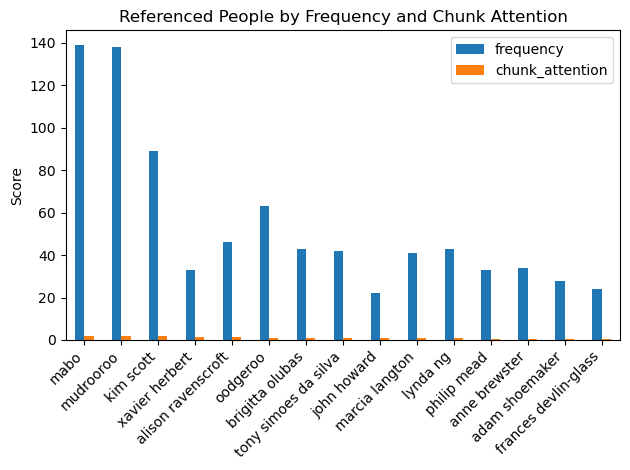

In [31]:
top_n = 15

comparison_df.head(top_n)[["frequency", "chunk_attention"]].plot(kind="bar")
plt.title("Referenced People by Frequency and Chunk Attention")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [32]:
dominant_figures_df = pd.DataFrame({
    "dominant_by_frequency": df_freq.idxmax(axis=1),
    "max_frequency": df_freq.max(axis=1),
    "dominant_by_spread_attention": df_spread_attention.idxmax(axis=1),
    "max_spread_attention": df_spread_attention.max(axis=1),
    "dominant_by_chunk_attention": df_chunk_attention.idxmax(axis=1),
    "max_chunk_attention": df_chunk_attention.max(axis=1),
})

dominant_figures_df.head(20)

,dominant_by_frequency,max_frequency,dominant_by_spread_attention,max_spread_attention,dominant_by_chunk_attention,max_chunk_attention
01 Sep 2007 - Australian Women's Book Review: Online - Trove,kim scott,0,kim scott,0.000000,kim scott,0.000000
2006-01-01__ferrier-carole__australian-womens-book-review__the-best-australian-novel-for-years__book-review,kim scott,0,kim scott,0.000000,kim scott,0.000000
2006-08-19__ravenscroft-alison__the-age__when-the-narrators-art-matches-the-magical-storytelling__book-review,kim scott,0,alison ravenscroft,0.000264,alison ravenscroft,0.250000
2006-09-02__anonymous__the-canberra-times__calming-influence-in-balance-fraught-with-pain__book-review,mabo,1,mabo,0.000172,mabo,0.166667
2006-09-09__osullivan-jane__the-age__from-here-to-carpentaria__book-review,kim scott,0,xavier herbert,0.000093,xavier herbert,0.090909
2006-09-16__davison-liam__the-sydney-morning-herald__phantasmagorical-tale-fills-a-legendary-landscape__book-review,kim scott,0,alison ravenscroft,0.000115,alison ravenscroft,0.111111
2006-09-30__england-katherine__the-advertiser__small-town-dreaming__book-review,kim scott,0,xavier herbert,0.000241,xavier herbert,0.250000
2006-10-01__mcfadyen-kate__australian-book-review__carpentaria-by-alexis-wright__book-review,kim scott,0,kim scott,0.000000,kim scott,0.000000
2006-10-04__grossman-michelle__the-australian__risk-roguery-amd-revelation__book-review,kim scott,0,kim scott,0.000168,kim scott,0.166667
2007-01-01__coles-david__ngoonjook__carpentaria__book-review,xavier herbert,1,xavier herbert,0.000057,xavier herbert,0.058824


In [33]:
output_dir = PROJECT_ROOT / "outputs"
output_dir.mkdir(exist_ok=True)

top_people_df.to_csv(output_dir / "top_people_raw.csv", index=False)
consolidated_top_people_df.to_csv(output_dir / "top_people_consolidated.csv", index=False)

df_freq.to_csv(output_dir / "person_frequency_by_document.csv")
df_spread_attention.to_csv(output_dir / "person_spread_attention_by_document.csv")
df_chunk_attention.to_csv(output_dir / "person_chunk_attention_by_document.csv")

comparison_df.to_csv(output_dir / "person_corpus_comparison.csv")
dominant_figures_df.to_csv(output_dir / "dominant_figures_by_document.csv")

print(f"Saved outputs to {output_dir}")

Saved outputs to /Users/FMOR/Documents/GitHub/citational_refusal/outputs
